In [7]:
import torch
import torch.nn as nn

class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        self.feature_extractor = nn.Sequential(
            # C1: Layer 1 - Convolutional (Input: 32x32x1, Output: 28x28x6)
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            # S2: Layer 2 - Max Pooling (Output: 14x14x6)
            nn.MaxPool2d(kernel_size=2, stride=2),
            # C3: Layer 3 - Convolutional (Output: 10x10x16)
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1),
            nn.ReLU(),
            # S4: Layer 4 - Max Pooling (Output: 5x5x16)
            nn.MaxPool2d(kernel_size=2, stride=2),
            # C5: Layer 5 - Convolutional (Output: 1x1x120)
            nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5, stride=1),
            nn.ReLU()
        )
        self.classifier = nn.Sequential(
            # F6: Layer 6 - Fully Connected (Input: 120, Output: 84)
            nn.Linear(in_features=120, out_features=84),
            nn.ReLU(),
            # Output: Fully Connected (Input: 84, Output: 10)
            nn.Linear(in_features=84, out_features=num_classes),
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.flatten(x, 1)
        logits = self.classifier(x)
        return logits

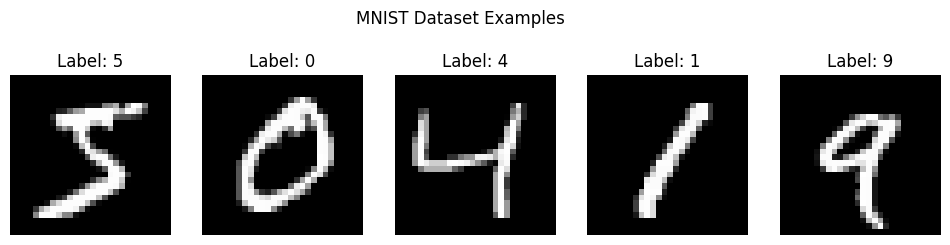

In [22]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Define transformations (Convert to tensor)
transform = transforms.Compose([transforms.ToTensor()])

# Download and load MNIST dataset (Training)
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Show some examples
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    img, label = train_dataset[i]
    # Remove channel dimension for matplotlib (1, 28, 28) -> (28, 28)
    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(f'Label: {label}')
    axes[i].axis('off')

plt.suptitle('MNIST Dataset Examples')
plt.show()

In [23]:
from torch.utils.data import DataLoader
import torch.optim as optim

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters
batch_size = 64
learning_rate = 0.001
epochs = 5

# DataLoaders
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

# Initialize model, loss function and optimizer
model = LeNet5().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training Loop
model.train()
for epoch in range(epochs):
    running_loss = 0.0
    for batch_idx, (data, targets) in enumerate(train_loader):
        # Send data to device (GPU or CPU)
        data = data.to(device)
        targets = targets.to(device)

        # Forward pass
        scores = model(data)
        loss = criterion(scores, targets)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
        if (batch_idx + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Step [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

print("Training completed!")

Epoch [1/5], Step [100/938], Loss: 0.2473
Epoch [1/5], Step [200/938], Loss: 0.1566
Epoch [1/5], Step [300/938], Loss: 0.3117
Epoch [1/5], Step [400/938], Loss: 0.1187
Epoch [1/5], Step [500/938], Loss: 0.1733
Epoch [1/5], Step [600/938], Loss: 0.1399
Epoch [1/5], Step [700/938], Loss: 0.0942
Epoch [1/5], Step [800/938], Loss: 0.1820
Epoch [1/5], Step [900/938], Loss: 0.0308
Epoch [2/5], Step [100/938], Loss: 0.1134
Epoch [2/5], Step [200/938], Loss: 0.0731
Epoch [2/5], Step [300/938], Loss: 0.1503
Epoch [2/5], Step [400/938], Loss: 0.0873
Epoch [2/5], Step [500/938], Loss: 0.0277
Epoch [2/5], Step [600/938], Loss: 0.0205
Epoch [2/5], Step [700/938], Loss: 0.0275
Epoch [2/5], Step [800/938], Loss: 0.2868
Epoch [2/5], Step [900/938], Loss: 0.0152
Epoch [3/5], Step [100/938], Loss: 0.0761
Epoch [3/5], Step [200/938], Loss: 0.1134
Epoch [3/5], Step [300/938], Loss: 0.0433
Epoch [3/5], Step [400/938], Loss: 0.0634
Epoch [3/5], Step [500/938], Loss: 0.0460
Epoch [3/5], Step [600/938], Loss:

In [24]:
# Download and load MNIST dataset (Test)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# Evaluation on the test set
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for data, targets in test_loader:
        data = data.to(device)
        targets = targets.to(device)
        
        outputs = model(data)
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy on the test set (10,000 images): {accuracy:.2f}%')

Accuracy on the test set (10,000 images): 98.89%


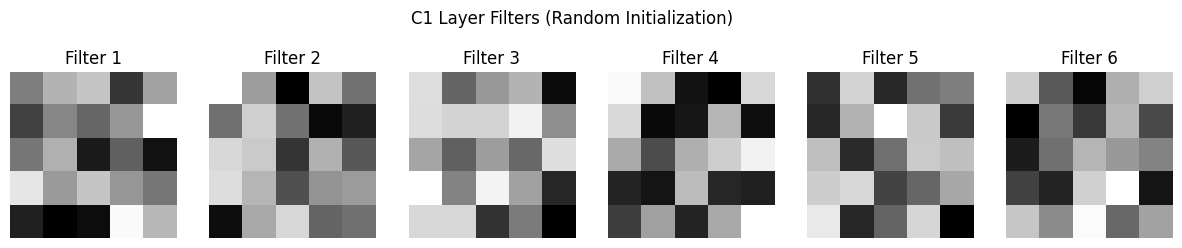

In [25]:
import matplotlib.pyplot as plt

# Instantiate the model
model = LeNet5()

# Get weights from the first convolutional layer (C1)
# Shape: [6, 1, 5, 5] (6 filters, 1 channel, 5x5 pixels)
weights = model.feature_extractor[0].weight.data.cpu().numpy()

# Visualize the 6 filters
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i in range(6):
    axes[i].imshow(weights[i, 0], cmap='gray')
    axes[i].set_title(f'Filter {i+1}')
    axes[i].axis('off')

plt.suptitle('C1 Layer Filters (Random Initialization)')
plt.show()

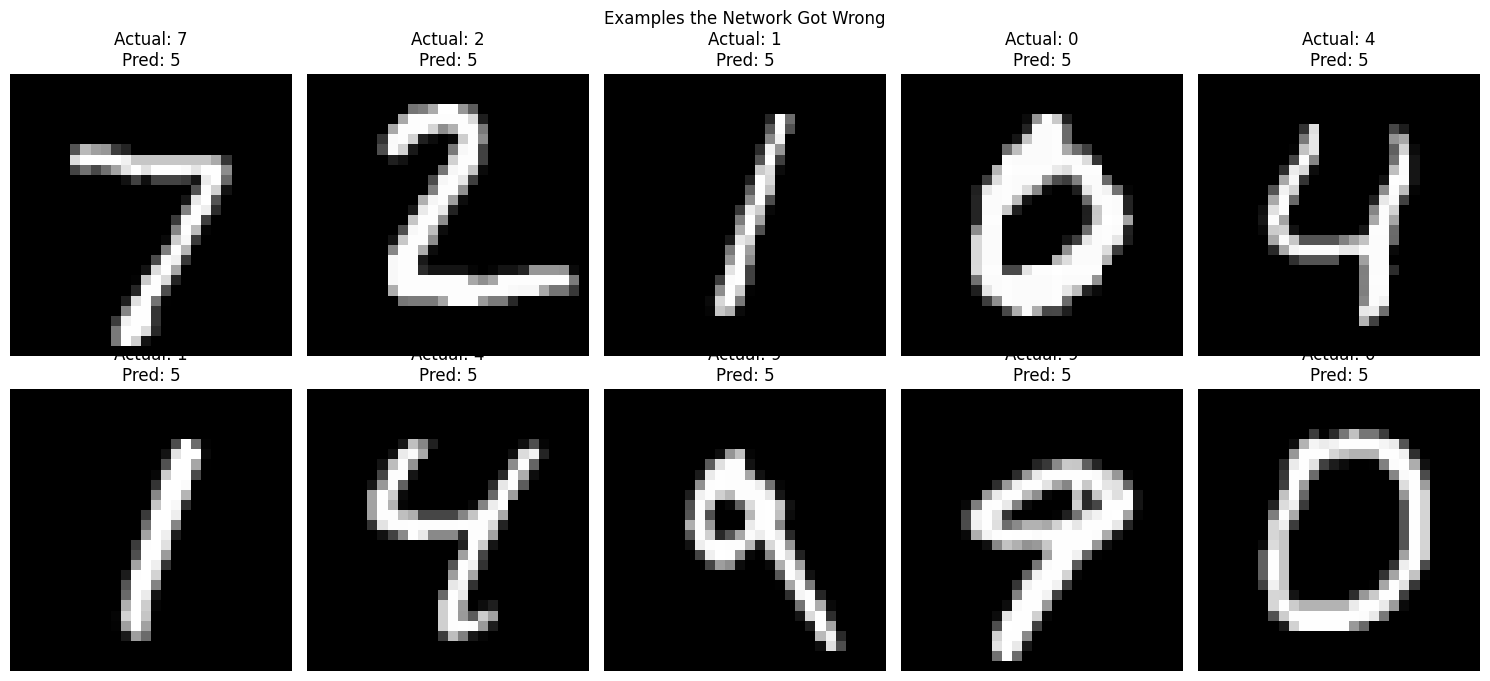

In [31]:
import numpy as np

model.eval()
misclassified_images = []
misclassified_labels = []
misclassified_preds = []

with torch.no_grad():
    for data, targets in test_loader:
        data, targets = data.to(device), targets.to(device)
        outputs = model(data)
        _, predicted = torch.max(outputs, 1)
        
        # Identify where prediction differs from target
        mask = (predicted != targets)
        
        if mask.any():
            misclassified_images.extend(data[mask].cpu())
            misclassified_labels.extend(targets[mask].cpu())
            misclassified_preds.extend(predicted[mask].cpu())
            
        if len(misclassified_images) >= 10:
            break

# Plot the errors
num_errors = min(len(misclassified_images), 10)
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

for i in range(num_errors):
    img = misclassified_images[i].squeeze()
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'Actual: {misclassified_labels[i]}\nPred: {misclassified_preds[i]}')
    axes[i].axis('off')

plt.suptitle('Examples the Network Got Wrong')
plt.tight_layout()
plt.show()

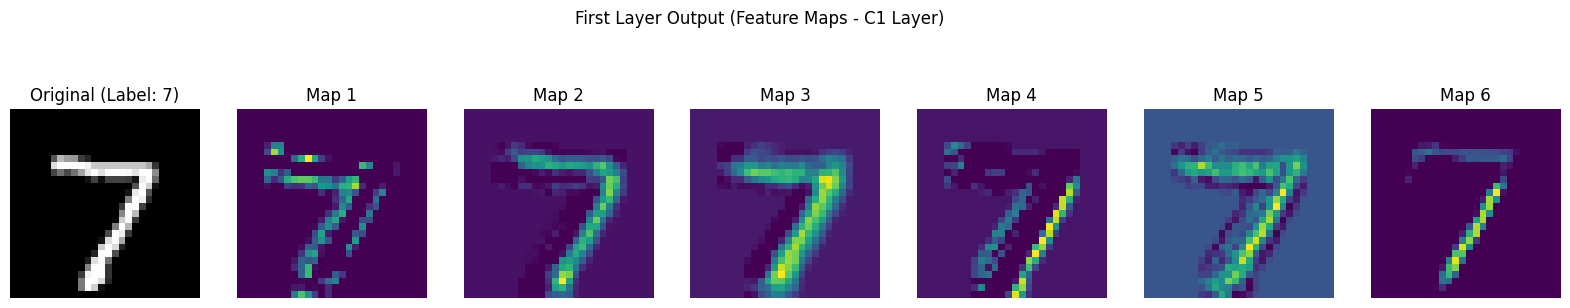

In [28]:
# Get a single image from the test dataset
image, label = test_dataset[0]
image_unsqueezed = image.unsqueeze(0).to(device) # Add batch dimension (1, 1, 28, 28)

# Pass the image through the first layer only (C1 + ReLU)
with torch.no_grad():
    # Layer C1 is the first element of Sequential (index 0)
    # ReLU activation is the second element (index 1)
    first_layer_conv = model.feature_extractor[0](image_unsqueezed)
    first_layer_activation = model.feature_extractor[1](first_layer_conv)

# Convert to numpy for visualization
feature_maps = first_layer_activation.squeeze().cpu().numpy()

# Plot original image and the 6 resulting feature maps
fig, axes = plt.subplots(1, 7, figsize=(20, 4))

# Imagem Original
axes[0].imshow(image.squeeze(), cmap='gray')
axes[0].set_title(f'Original (Label: {label})')
axes[0].axis('off')

# Mapas de Características
for i in range(6):
    axes[i+1].imshow(feature_maps[i], cmap='viridis')
    axes[i+1].set_title(f'Map {i+1}')
    axes[i+1].axis('off')

plt.suptitle('First Layer Output (Feature Maps - C1 Layer)')
plt.show()

In [29]:
# Save model state (weights and bias)
torch.save(model.state_dict(), 'lenet5_mnist.pth')
print('Model saved successfully as lenet5_mnist.pth!')

# Example of how to load:
# model = LeNet5()
# model.load_state_dict(torch.load('lenet5_mnist.pth'))
# model.to(device)

Model saved successfully as lenet5_mnist.pth!


In [30]:
# 1. Instantiate the model architecture
loaded_model = LeNet5()

# 2. Load the weights dictionary from the saved file
# Note: Ensure 'lenet5_mnist.pth' exists in the directory
loaded_model.load_state_dict(torch.load('lenet5_mnist.pth', weights_only=True))

# 3. Move to the correct device (CPU or GPU)
loaded_model = loaded_model.to(device)

# 4. Set to evaluation mode
loaded_model.eval()

print('Model loaded successfully from saved weights!')

Model loaded successfully from saved weights!
